In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sql_queries.analytics import monthly_revenue, top_product, customer_segmentation 
from database.db_connect import get_connection

sns.set_style("darkgrid")

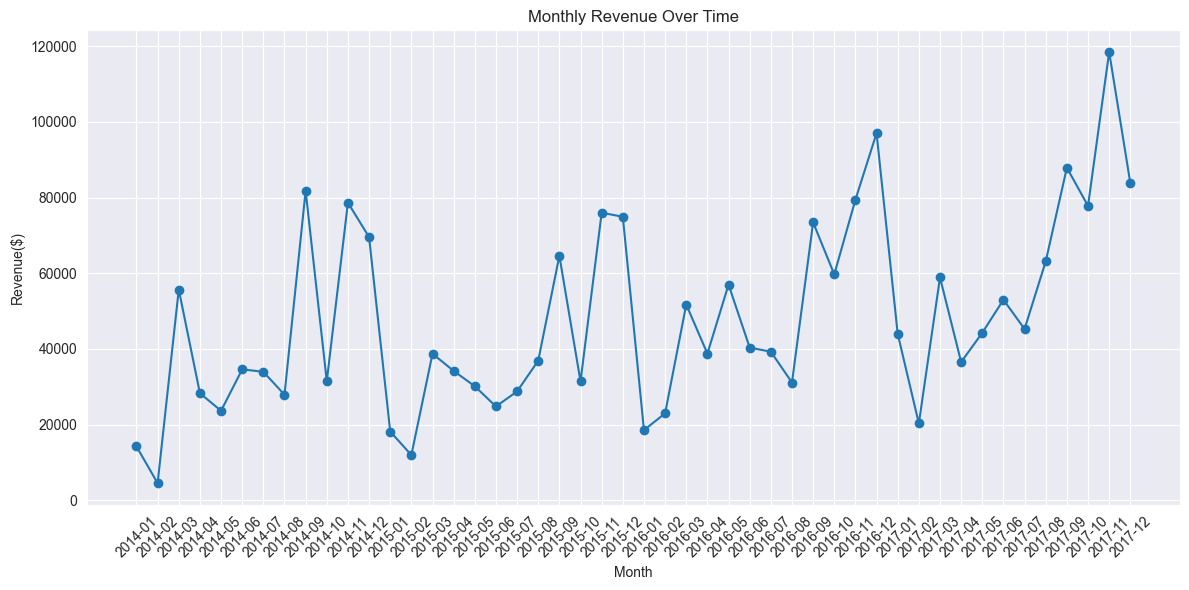

In [2]:
revenue_df = monthly_revenue()

plt.figure(figsize=(12, 6))
plt.plot(revenue_df['month'], revenue_df['total_revenue'], marker='o')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\welcome\AppData\Local\Temp\ipykernel_11504\3612616450.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=products_df, y='product_name', x='total_sales', palette='viridis')


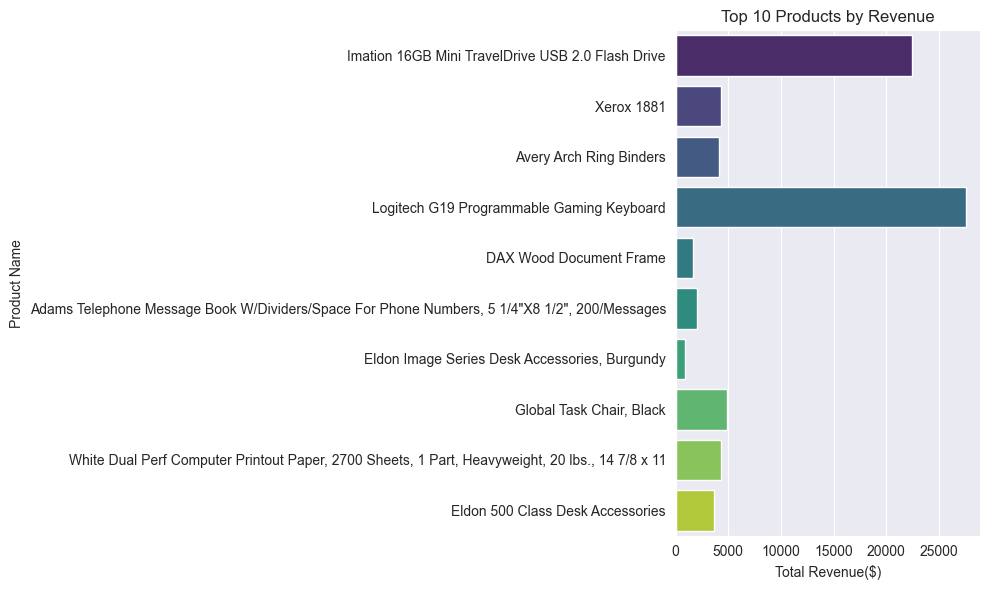

In [3]:
products_df = top_product(limit=10)

plt.figure(figsize=(10, 6))
sns.barplot(data=products_df, y='product_name', x='total_sales', palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

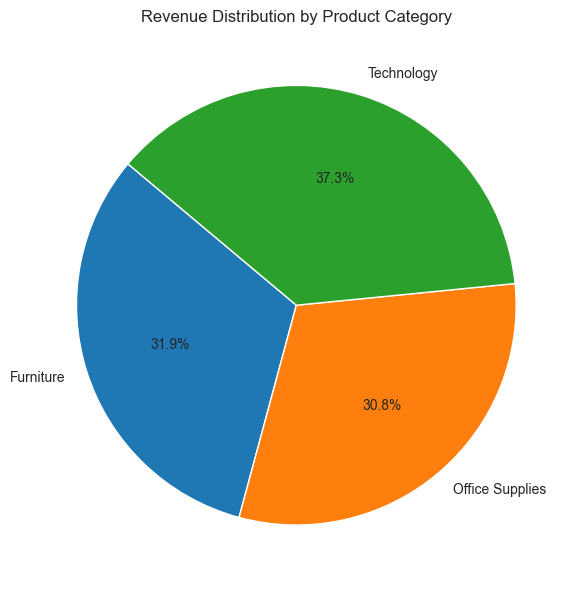

In [4]:
conn = get_connection()
category_df = pd.read_sql_query("""
SELECT p.category, SUM(oi.sales) as total_sales
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.category
""", conn)
conn.close()

plt.figure(figsize=(8, 6))
plt.pie(category_df['total_sales'], labels=category_df['category'], autopct='%1.1f%%', startangle=140)
plt.title('Revenue Distribution by Product Category')
plt.tight_layout()
plt.show()

In [5]:
conn = get_connection()
check_df = pd.read_sql_query("SELECT COUNT(*) as total FROM order_items", conn)
print(check_df)
conn.close()

   total
0   9994


### Key Insight

+ Sales peak in November-December (holiday season effect)
+ Technology category generates the highest revenue
+ Top 3 products contribute 15% of total sales